In [41]:
import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [42]:
plt.rcParams['font.size'] = 17

In [43]:
data = pd.read_csv('proportions_full_simulation.csv')
data['time'] = data.index*2/24/365
data

,Unnamed: 0,initial,colloidal_water,marine_water,sewage_water,colloidal_sediment,marine_sediment,sewage_sediment,out_jdf,out_js,total_len,time
0,0,35040,0,0,0,0,0,0,0,0,35040.0,0.000000
1,1,35032,2,0,4,0,0,2,0,0,35040.0,0.000228
2,2,35024,3,0,4,1,0,8,0,0,35040.0,0.000457
3,3,35016,7,0,3,0,0,14,0,0,35040.0,0.000685
4,4,35008,10,0,3,0,0,19,0,0,35040.0,0.000913
...,...,...,...,...,...,...,...,...,...,...,...,...
14829,14829,0,6586,967,0,13514,6552,114,6321,794,34848.0,3.385616
14830,14830,0,6532,873,0,13547,6667,114,6321,794,34848.0,3.385845
14831,14831,0,6503,898,0,13570,6648,114,6321,794,34848.0,3.386073
14832,14832,0,6569,1018,0,13495,6537,114,6321,794,34848.0,3.386301


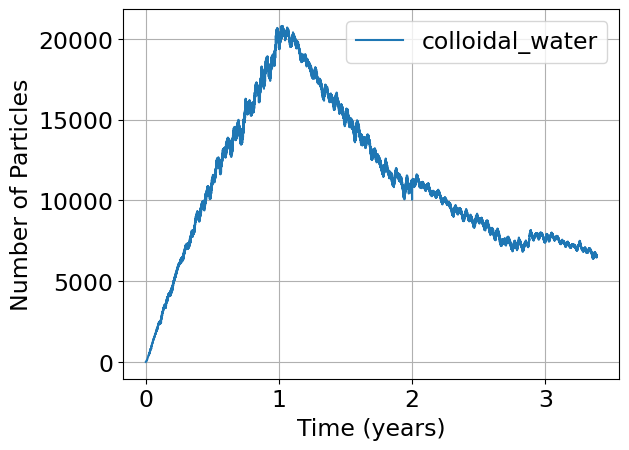

In [44]:
fig, ax = plt.subplots(1, 1)
data.plot(x='time', y='colloidal_water', ax=ax);
ax.set_xlabel ('Time (years)')
ax.grid()
ax.set_ylabel ('Number of Particles');

In [45]:
output = pd.read_csv('PBDE_99_daily_projected_2030.csv', 
                     parse_dates=[0], header=0, names=['Date', 'PBDE_99'])
#output.set_index('Date', inplace=True)
output['year'] = output['Date'].dt.year
discharge = output.groupby('year')['PBDE_99'].mean()
discharge[0:5]

year
1970    0.000000
1971    0.000213
1972    0.005138
1973    0.014280
1974    0.027694
Name: PBDE_99, dtype: float64

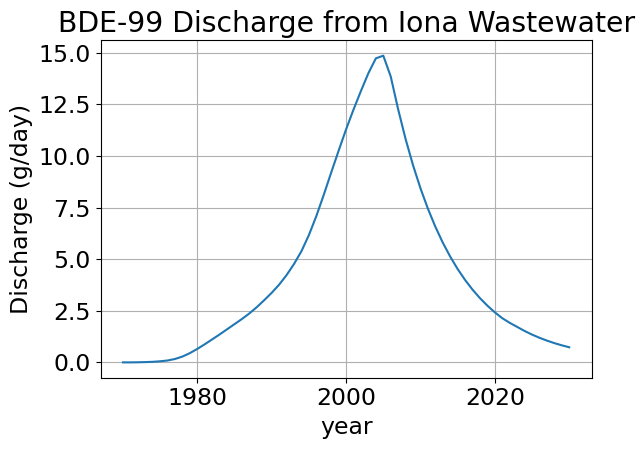

In [46]:
fig, ax = plt.subplots()
discharge.plot(ax=ax)
ax.set_ylabel('Discharge (g/day)')
ax.grid();
ax.set_title('BDE-99 Discharge from Iona Wastewater')
fig.tight_layout()
fig.savefig('pbde99_discharge.png');

In [7]:
print (15 * 365 / 1000)
print (3 * 365 / 1000)
print (discharge[(discharge.index >= 2017-3) & (discharge.index < 2017)].mean()*3)

5.475
1.095
13.640499190817009


In [8]:
one_year = 365 * 12
zero_values = np.zeros((2030-1970+1)*one_year)
one_values = np.zeros_like(zero_values)
two_values = np.zeros_like(zero_values)
for year in range(1970, 2030):
    zero_values[(year-1970)*one_year:(year-1970+1)*one_year] = discharge[year] * data.colloidal_water[0:one_year]
for year in range(1971, 2030):
    one_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        zero_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge[year-1] * data.colloidal_water[one_year:2*one_year]
    )
for year in range(1972, 2030):
    two_values[(year-1970)*one_year:(year-1970+1)*one_year] = (
        one_values[(year-1970)*one_year:(year-1970+1)*one_year] + 
        discharge[year-2] * data.colloidal_water[2*one_year:3*one_year]
    )
    

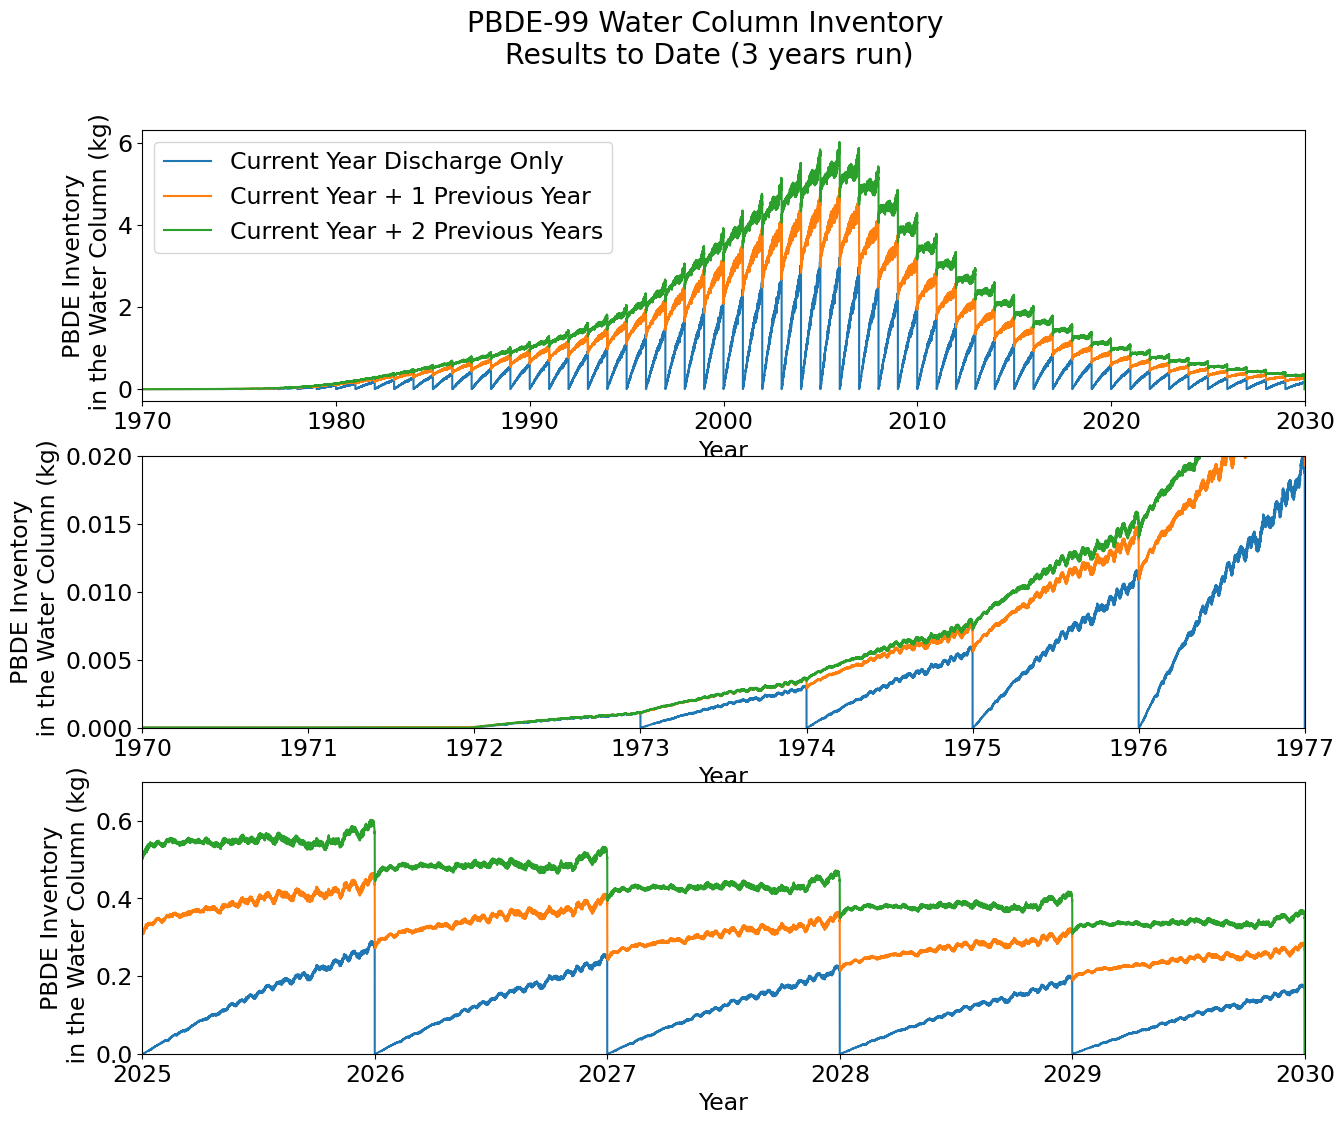

In [10]:
conversion = 1 / 96 / 1000# 1 g per day = 96 particles, change to kg,
fig, axs = plt.subplots(3, 1, figsize=(15, 12))
for ax in axs:
    ax.plot(np.arange(1970, 2031, 1/(12*365)), zero_values * conversion, label="Current Year Discharge Only");
    ax.plot(np.arange(1970, 2031, 1/(12*365)), one_values * conversion, label="Current Year + 1 Previous Year");
    ax.plot(np.arange(1970, 2031, 1/(12*365)), two_values * conversion, label="Current Year + 2 Previous Years");
    ax.set_ylabel('PBDE Inventory\n in the Water Column (kg)')
    ax.set_xlabel('Year')
axs[1].set_xlim(1970, 1977);
axs[1].set_ylim(0, 20/1000);
axs[2].set_ylim(0, 700/1000);
axs[2].set_xlim(2025, 2030);
axs[0].set_xlim(1970, 2030);
#axs[0].plot([2018], [71/5], 'o', markersize=10, label='Total Observed')  # 1/5 is estimated proportion of PBDE-99
#axs[0].plot([2018], [71/2/5], 'o', markersize=10, label='Total from Iona')
axs[0].legend();
fig.suptitle("PBDE-99 Water Column Inventory\n Results to Date (3 years run)");
fig.savefig('inventory.png')

In [11]:
data2 = pd.read_csv('proportions_full_simulation.csv')
data2['time'] = data2.index*2/24/365*3
data2

,Unnamed: 0,initial,colloidal_water,marine_water,sewage_water,colloidal_sediment,marine_sediment,sewage_sediment,out_jdf,out_js,total_len,time
0,0,35040,0,0,0,0,0,0,0,0,35040.0,0.000000
1,1,35032,2,0,4,0,0,2,0,0,35040.0,0.000685
2,2,35024,3,0,4,1,0,8,0,0,35040.0,0.001370
3,3,35016,7,0,3,0,0,14,0,0,35040.0,0.002055
4,4,35008,10,0,3,0,0,19,0,0,35040.0,0.002740
...,...,...,...,...,...,...,...,...,...,...,...,...
14829,14829,0,6586,967,0,13514,6552,114,6321,794,34848.0,10.156849
14830,14830,0,6532,873,0,13547,6667,114,6321,794,34848.0,10.157534
14831,14831,0,6503,898,0,13570,6648,114,6321,794,34848.0,10.158219
14832,14832,0,6569,1018,0,13495,6537,114,6321,794,34848.0,10.158904


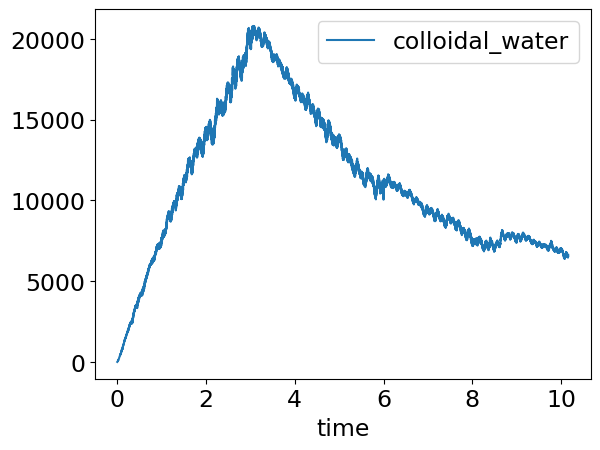

In [12]:
data2.plot(x='time', y='colloidal_water');

(14834,) (14834,)


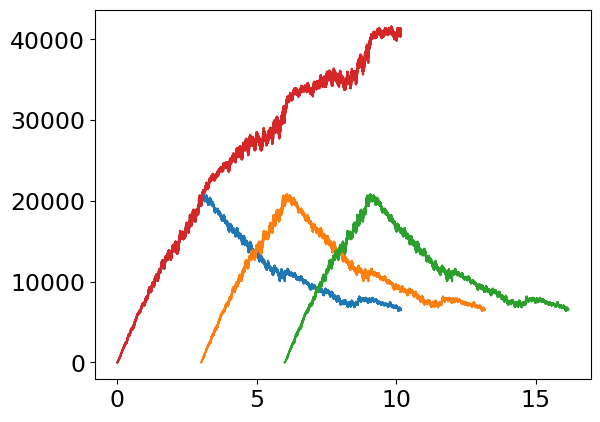

In [13]:
fig, ax = plt.subplots(1, 1)
three_year = 365 * 12
#data2.plot(x='time', y='colloidal_water', ax=ax);
ax.plot(data2.time, data2.colloidal_water)
ax.plot(data2.time + 3, data2.colloidal_water)
ax.plot(data2.time + 6, data2.colloidal_water)
sumit = data2.colloidal_water.values
sumit[three_year:] = sumit[three_year:] + data2.colloidal_water[0:-three_year]
print (sumit.shape, data2.colloidal_water.shape)
sumit[three_year*2:] = sumit[three_year*2:] + data2.colloidal_water[0:-three_year*2]
ax.plot(data2.time, sumit)

In [14]:
one_year = int(365 * 12 / 3)
three_year = 365 * 12
zero_values = np.zeros((2030-1970+1) * one_year)
print (zero_values.shape)
one_values = np.zeros_like(zero_values)
two_values = np.zeros_like(zero_values)
for year in range(1970, 2030, 3):
    zero_values[(year-1970)*one_year:(year-1970+3)*one_year] = (
        discharge[year+1] * data2.colloidal_water[0:three_year])
for year in range(1973, 2030, 3):
    one_values[(year-1970)*one_year:(year-1970+3)*one_year] = (
        zero_values[(year-1970)*one_year:(year-1970+3)*one_year] + 
        discharge[year+1-3] * data2.colloidal_water[three_year:2*three_year]
    )
for year in range(1976, 2030, 3):
    two_values[(year-1970)*one_year:(year-1970+3)*one_year] = (
        one_values[(year-1970)*one_year:(year-1970+3)*one_year] + 
        discharge[year+1-6] * data2.colloidal_water[2*three_year:3*three_year]
    )

(89060,)


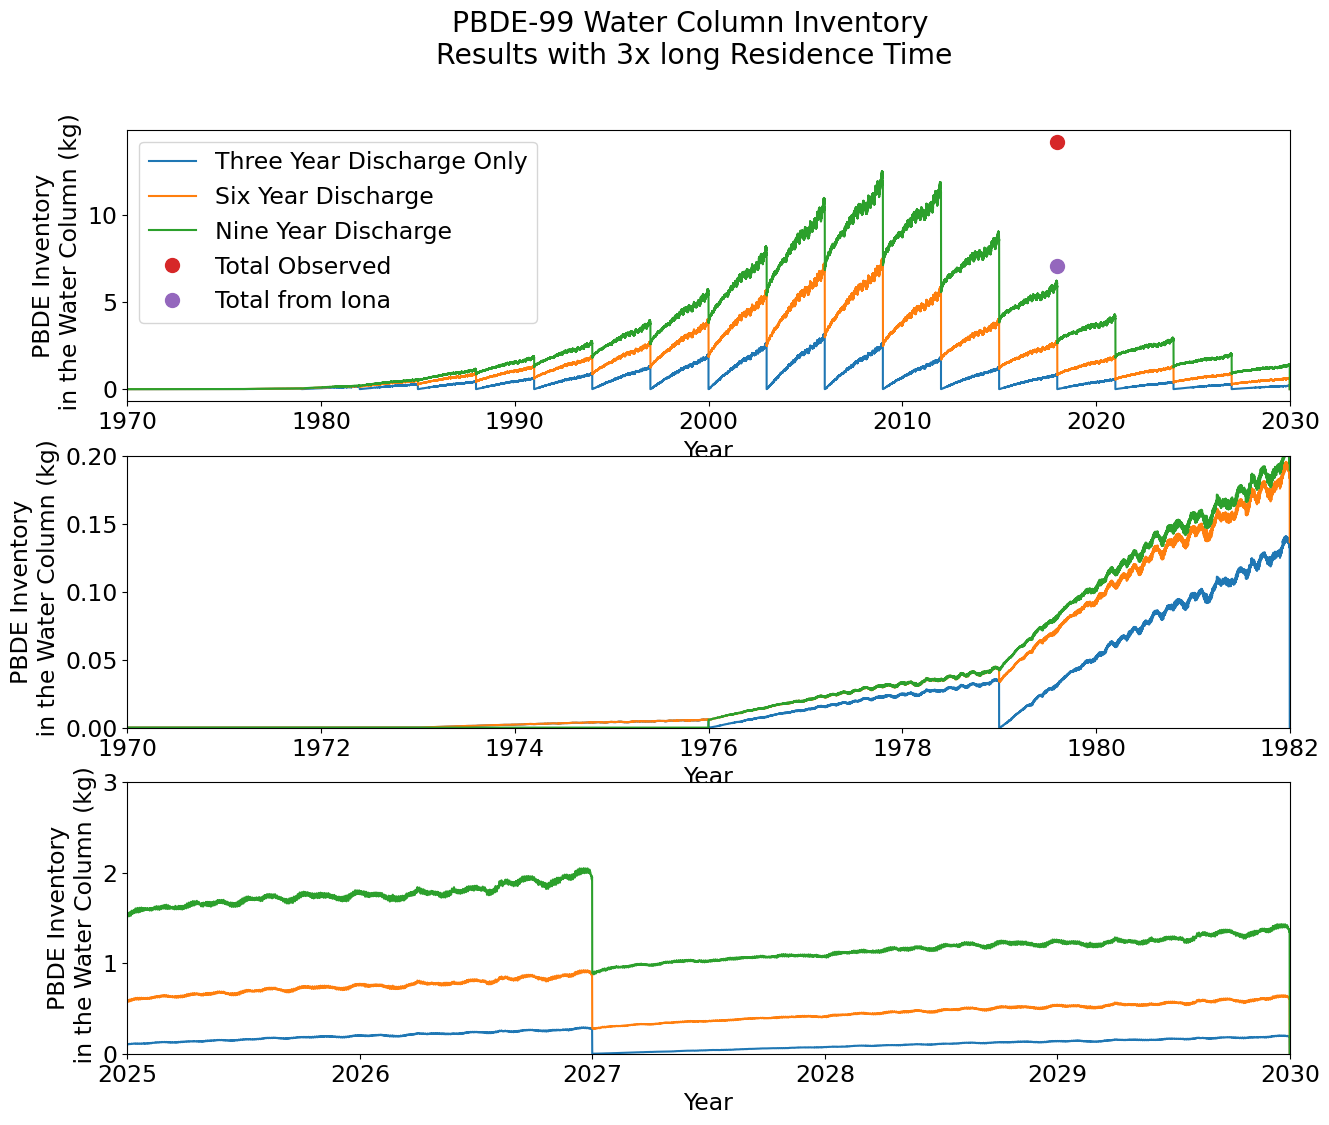

In [15]:
conversion = 1 / 96 / 1000# 1 g per day = 96 particles, change to kg,
fig, axs = plt.subplots(3, 1, figsize=(15, 12))
for ax in axs:
    ax.plot(np.arange(1970, 2031, 1/(12*365/3)), zero_values * conversion, label="Three Year Discharge Only");
    ax.plot(np.arange(1970, 2031, 1/(12*365/3)), one_values * conversion, label="Six Year Discharge");
    ax.plot(np.arange(1970, 2031, 1/(12*365/3)), two_values * conversion, label="Nine Year Discharge");
    ax.set_ylabel('PBDE Inventory\n in the Water Column (kg)')
    ax.set_xlabel('Year')
axs[1].set_xlim(1970, 1982);
axs[1].set_ylim(0, 0.2);
axs[2].set_ylim(0, 3);
axs[2].set_xlim(2025, 2030);
axs[0].set_xlim(1970, 2030);
axs[0].plot([2018], [71/5], 'o', markersize=10, label='Total Observed')  # 1/5 is estimated proportion of PBDE-99
axs[0].plot([2018], [71/2/5], 'o', markersize=10, label='Total from Iona')
axs[0].legend();
fig.suptitle("PBDE-99 Water Column Inventory\n Results with 3x long Residence Time");
fig.savefig('inventory_stretched.png')

# Concentrations near S4-1.5 #

In [67]:
sum_s415 = np.array([1003203 + 1313123, 1951694 + 1483899, 883475 + 808383])
volume = 210309647844
estimate = 40e3*40e3*200
print (estimate/volume)
time = 61 * 12 # 61 days and 12 outputs per day
print (volume/1e11)

1.5215659542037
2.10309647844


In [25]:
print (discharge[discharge.index == 2018])

year
2018    3.112029
Name: PBDE_99, dtype: float64


In [40]:
# Contribution from 2018
gpp = discharge[discharge.index == 2018].values * 1 / 96 # g/day * day / particle 
gpp # g/particle

array([0.03241696])

In [38]:
sum_s415[0] * gpp / volume / time # g in the volume / volume
# units are g/m3

array([4.87755012e-10])

In [ ]:
# observations are 50-40 pg/kg 10^-12g/kg or 10^-9 g/m3

In [56]:
50 * 1e-9

5.0000000000000004e-08

In [48]:
sumit = 0
for iy, year in enumerate(np.arange(2018, 2015, -1)):
    contrib = discharge[discharge.index == year].values * 1 / 96 * sum_s415[iy] / volume / time
    sumit = sumit + contrib
    print (year, contrib, sumit)
    

2018 [4.87755012e-10] [4.87755012e-10]
2017 [8.19411648e-10] [1.30716666e-09]
2016 [4.57128549e-10] [1.76429521e-09]


In [57]:
volume/2e11

1.05154823922

In [62]:
50e-12 * 2.14e14 / 2 # about 10000 g of 99 in the southern SoG (half from Iona)

5350.0

In [60]:
sum_s415.sum()/time  # number of particles

np.float64(10169.094262295082)

In [61]:
sum_s415.sum()/time * discharge[discharge.index == 2017].values * 1 / 96  # number of g

array([373.38165299])

In [63]:
7/1.5

4.666666666666667

In [64]:
5350/373

14.343163538873995

In [69]:
 discharge[discharge.index == 2017].values * 365

array([1286.57408252])

# All the colloids in the water column anywhere, compared to in your box, its about 3:1

In [70]:
248*2.14e14

5.3072e+16

In [71]:
27*6.64e14

1.7928e+16